# Injection d'erreurs — Partie Yasser
## Projet : Vers une évaluation fiable des workflows de data preparation générés par LLM

**Étudiant :** Yasser
**Tâches assignées :** Erreurs de format · Valeurs aberrantes (Outliers)
**Dataset :** `hotel_bookings.csv` (Hotel Booking Demand)
**Phase du projet :** Phase 2 — Construction des datasets bruités

---

### Objectif de ce notebook

Ce notebook construit, pour le dataset `hotel_bookings.csv`, deux jeux d'erreurs contrôlées et
traçables, correspondant aux deux catégories qui me sont assignées dans la répartition des tâches
du groupe :

| Type d'erreur | Objectif d'évaluation (cf. cahier des charges) |
|---|---|
| **Erreurs de format** | Tester la capacité du workflow LLM à standardiser des formats hétérogènes (dates) |
| **Valeurs aberrantes (outliers)** | Tester la capacité du workflow LLM à détecter des anomalies numériques |

Chaque fonction d'injection respecte 3 principes imposés par le cahier des charges (Phase 2) :

1. **Reproductibilité** : une graine aléatoire fixe (`random_state`) garantit que la même exécution
   produit toujours le même bruit.
2. **Traçabilité** : chaque erreur injectée est enregistrée dans un journal (`error_log`) contenant
   la ligne, la colonne, la valeur d'origine, la valeur injectée et le type d'erreur. Ce journal
   servira plus tard (Phase 5) à calculer les métriques de qualité (précision/rappel de correction).
3. **Non-destructivité** : le dataset original n'est jamais modifié — chaque fonction retourne une
   copie bruitée.


## 1. Imports et chargement des données

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adapter le chemin selon l'environnement (local / Kaggle / Colab)
df = pd.read_csv("/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv")

print(f"Dimensions du dataset original : {df.shape}")
df.head()

Dimensions du dataset original : (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Fonction 1 — Injection d'erreurs de format

### Principe

La colonne `reservation_status_date` est initialement stockée dans un format homogène
(`YYYY-MM-DD`). La fonction sélectionne aléatoirement une proportion `error_rate` des lignes et
réécrit la date dans un **format différent**, choisi parmi 6 variantes réalistes :

| Variante | Exemple |
|---|---|
| Jour/Mois/Année | `23/12/2015` |
| Mois/Jour/Année (format US, ambigu) | `12/23/2015` |
| Texte complet | `December 23, 2015` |
| Jour-Mois abrégé-Année | `23-Dec-2015` |
| Année/Mois/Jour | `2015/12/23` |
| Timestamp Unix brut | `1450828800` |

### Pourquoi ces variantes ?

Elles reproduisent des erreurs réellement rencontrées lors de l'intégration de données provenant
de sources hétérogènes (export Excel, API différentes, saisie manuelle, systèmes legacy). Le format
`MM/DD/YYYY` est volontairement inclus car il crée une **ambiguïté réelle** (ex: `03/04/2015`
peut être le 3 avril ou le 4 mars), ce qui est un cas difficile et intéressant à tester pour un LLM.

### Paramètres

- `columns` : liste des colonnes de type date à corrompre (par défaut `reservation_status_date`)
- `error_rate` : proportion de lignes corrompues par colonne (0 à 1)
- `random_state` : graine de reproductibilité


In [41]:
def inject_format_errors(df, columns=None, error_rate=0.15, random_state=42):
    '''
    Injecte des incohérences de FORMAT sur des colonnes de type date.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset propre (version de référence).
    columns : list[str] or None
        Colonnes de type date à corrompre. Par défaut : ['reservation_status_date'].
    error_rate : float
        Proportion de cellules à corrompre par colonne (0 à 1).
    random_state : int
        Graine pour la reproductibilité.

    Returns
    -------
    df_noisy : pd.DataFrame
        Copie du dataset avec les formats de date corrompus.
    error_log : pd.DataFrame
        Journal des erreurs injectées : row_index, column, original_value,
        injected_value, error_type.
    '''
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()
    columns = columns or ["reservation_status_date"]
    log_records = []

    def reformat(date_str):
        try:
            d = pd.to_datetime(date_str)
        except Exception:
            return date_str, "unparsable_original"

        variants = [
            d.strftime("%d/%m/%Y"),          # 23/12/2015
            d.strftime("%m/%d/%Y"),          # 12/23/2015 (format US, ambigu)
            d.strftime("%B %d, %Y"),         # December 23, 2015
            d.strftime("%d-%b-%Y"),          # 23-Dec-2015
            d.strftime("%Y/%m/%d"),          # 2015/12/23
            str(int(d.timestamp())),         # timestamp brut
        ]
        choice = rng.integers(0, len(variants))
        return variants[choice], "date_format_inconsistency"

    for col in columns:
        if col not in df_noisy.columns:
            continue
        n_rows = len(df_noisy)
        n_to_corrupt = int(n_rows * error_rate)
        idx_to_corrupt = rng.choice(n_rows, size=n_to_corrupt, replace=False)

        for idx in idx_to_corrupt:
            original_value = df_noisy.at[idx, col]
            new_value, err_type = reformat(original_value)
            df_noisy.at[idx, col] = new_value
            log_records.append({
                "row_index": idx,
                "column": col,
                "original_value": original_value,
                "injected_value": new_value,
                "error_type": err_type,
            })

    error_log = pd.DataFrame(log_records)
    return df_noisy, error_log

## 3. Fonction 2 — Injection de valeurs aberrantes (outliers)

### Principe

Pour chaque colonne numérique ciblée, la fonction tire aléatoirement `error_rate` % des lignes et
remplace la valeur par une valeur **hors du domaine réaliste**, générée uniformément entre une borne
minimale et maximale volontairement excessive.

### Colonnes ciblées et justification des bornes

Les bornes ont été calibrées à partir des statistiques descriptives réelles du dataset
(`df.describe()`), en choisissant des valeurs nettement au-delà du domaine plausible :

| Colonne | Domaine réaliste observé | Plage d'outliers injectés | Justification |
|---|---|---|---|
| `adr` (tarif journalier) | ~0 à 300 € | -500 à 10 000 € | Tarif négatif (erreur de saisie) ou extrême (erreur de capteur/API) |
| `lead_time` | 0 à ~737 jours | 2000 à 5000 jours | Réservation faite plus de 5 ans à l'avance : irréaliste |
| `adults` | 1 à ~4 | 30 à 100 | Nombre d'adultes impossible pour une réservation standard |
| `babies` | 0 à ~2 | 10 à 50 | Nombre de bébés irréaliste |
| `stays_in_week_nights` | 0 à ~50 | 200 à 1000 | Séjour de plusieurs mois : incohérent |
| `days_in_waiting_list` | 0 à ~391 | 2000 à 9000 | Liste d'attente disproportionnée |

### Pourquoi ces colonnes ?

Ce sont des colonnes numériques centrales pour l'analyse hôtelière (prix, durée, capacité), ce qui
permet de tester si le workflow LLM sait détecter des anomalies métier (et pas seulement des
anomalies statistiques génériques comme un simple filtre z-score).

### Paramètres

- `column_bounds` : dictionnaire `{colonne: (min, max)}` définissant la plage des valeurs aberrantes
- `error_rate` : proportion de lignes corrompues par colonne (0 à 1)
- `random_state` : graine de reproductibilité


In [42]:
def inject_outliers(df, column_bounds=None, error_rate=0.02, random_state=42):
    '''
    Injecte des valeurs ABERRANTES sur des colonnes numériques.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset propre (version de référence).
    column_bounds : dict or None
        Dictionnaire {colonne: (min, max)} définissant la plage des valeurs aberrantes.
        Par défaut, couvre adr, lead_time, adults, babies, stays_in_week_nights,
        days_in_waiting_list.
    error_rate : float
        Proportion de cellules à corrompre par colonne (0 à 1).
    random_state : int
        Graine pour la reproductibilité.

    Returns
    -------
    df_noisy : pd.DataFrame
        Copie du dataset avec des valeurs aberrantes injectées.
    error_log : pd.DataFrame
        Journal des erreurs injectées : row_index, column, original_value,
        injected_value, error_type.
    '''
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()
    log_records = []

    default_bounds = {
        "adr": (-500, 10000),
        "lead_time": (2000, 5000),
        "adults": (30, 100),
        "babies": (10, 50),
        "stays_in_week_nights": (200, 1000),
        "days_in_waiting_list": (2000, 9000),
    }
    column_bounds = column_bounds or default_bounds

    for col, (low, high) in column_bounds.items():
        if col not in df_noisy.columns:
            continue
        n_rows = len(df_noisy)
        n_to_corrupt = max(1, int(n_rows * error_rate))
        idx_to_corrupt = rng.choice(n_rows, size=n_to_corrupt, replace=False)

        for idx in idx_to_corrupt:
            original_value = df_noisy.at[idx, col]
            outlier_value = rng.uniform(low, high)
            if pd.api.types.is_integer_dtype(df[col]):
                outlier_value = int(outlier_value)
            else:
                outlier_value = round(float(outlier_value), 2)

            df_noisy.at[idx, col] = outlier_value
            log_records.append({
                "row_index": idx,
                "column": col,
                "original_value": original_value,
                "injected_value": outlier_value,
                "error_type": "outlier_value",
            })

    error_log = pd.DataFrame(log_records)
    return df_noisy, error_log

## 4. Application des fonctions sur le dataset

On applique les deux fonctions sur le dataset propre `df` :
- `error_rate=0.15` pour les erreurs de format (niveau de bruit moyen-fort, car une seule colonne
  est concernée)
- `error_rate=0.02` pour les outliers (niveau plus faible car appliqué à 6 colonnes simultanément,
  ce qui donne déjà un volume d'erreurs conséquent)


In [43]:
df_fmt, log_fmt = inject_format_errors(df, error_rate=0.15, random_state=42)
df_out, log_out = inject_outliers(df, error_rate=0.02, random_state=42)

print(f"Erreurs de format injectées : {len(log_fmt)}")
print(f"Outliers injectés          : {len(log_out)}")

Erreurs de format injectées : 17908
Outliers injectés          : 14322


## 5. Vérification — affichage des données avec erreurs

On affiche un échantillon des lignes modifiées pour valider visuellement l'injection.

In [44]:
print("Données avec erreurs de format :")
display(df_fmt.loc[log_fmt["row_index"], ["reservation_status_date"]].head(15))

print("\nDonnées avec valeurs aberrantes :")
display(df_out.loc[log_out["row_index"], ["adr", "lead_time", "adults", "babies",
                                           "stays_in_week_nights", "days_in_waiting_list"]].head(15))

Données avec erreurs de format :


,reservation_status_date
98413,2016/09/30
101585,"November 15, 2016"
110248,2017/04/24
48361,"March 22, 2016"
50859,05/12/2016
590,2015/04/23
29952,2016/11/10
23375,24-Apr-2016
108248,25-Mar-2017
44508,09/10/2015



Données avec valeurs aberrantes :


,adr,lead_time,adults,babies,stays_in_week_nights,days_in_waiting_list
16373,-28.76,41,2,0,6,0
104861,7354.75,11,1,0,0,0
57015,254.55,205,2,0,2,0
30888,5717.39,14,2,0,2,0
108508,7438.79,5,1,0,1,0
114161,3271.65,39,1,0,2,0
89898,-385.19,3,2,0,1,0
27697,5749.49,227,2,0,4,0
35153,9908.07,36,2,0,4,0
41496,2204.98,2,2,0,2,0


## 6. Statistiques résumées

Nombre d'erreurs injectées par colonne et par type — ces chiffres serviront de **vérité terrain**
lors de l'évaluation multi-objectifs (Phase 5), pour calculer le taux d'erreurs corrigées par les
workflows LLM.

In [45]:
print("--- Erreurs de format ---")
print(log_fmt.groupby("column").size())
print(f"Total : {len(log_fmt)}\n")

print("--- Outliers ---")
print(log_out.groupby("column").size())
print(f"Total : {len(log_out)}")

--- Erreurs de format ---
column
reservation_status_date    17908
dtype: int64
Total : 17908

--- Outliers ---
column
adr                     2387
adults                  2387
babies                  2387
days_in_waiting_list    2387
lead_time               2387
stays_in_week_nights    2387
dtype: int64
Total : 14322


## 7. Visualisation

Un histogramme du nombre d'erreurs injectées par colonne pour chaque type.

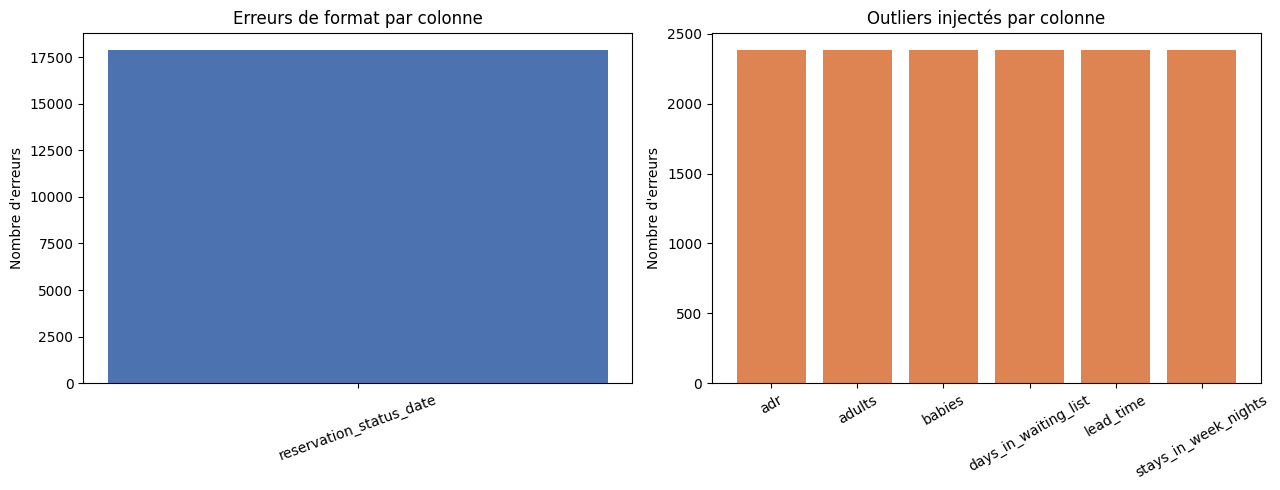

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts_fmt = log_fmt.groupby("column").size()
axes[0].bar(counts_fmt.index, counts_fmt.values, color="#4C72B0")
axes[0].set_title("Erreurs de format par colonne")
axes[0].set_ylabel("Nombre d'erreurs")
axes[0].tick_params(axis="x", rotation=20)

counts_out = log_out.groupby("column").size().sort_values(ascending=False)
axes[1].bar(counts_out.index, counts_out.values, color="#DD8452")
axes[1].set_title("Outliers injectés par colonne")
axes[1].set_ylabel("Nombre d'erreurs")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 8. Synthèse et livrables de cette partie

### Tableau récapitulatif

| Type d'erreur | Colonnes ciblées | Taux d'injection | Erreurs injectées |
|---|---|---|---|
| Format de date | `reservation_status_date` | 15% | voir résultat ci-dessus |
| Valeur aberrante | `adr`, `lead_time`, `adults`, `babies`, `stays_in_week_nights`, `days_in_waiting_list` | 2% par colonne | voir résultat ci-dessus |

### Ce que ce notebook fournit à l'équipe

1. Deux fonctions d'injection **paramétrables, reproductibles et traçables**, réutilisables sur
   les autres datasets du mini-benchmark (pas seulement `hotel_bookings.csv`).
2. Un **journal d'erreurs** (`error_log`) par fonction, qui constitue la vérité terrain nécessaire
   pour calculer les métriques de qualité en Phase 5 (précision, rappel, F1-score de correction).
3. Une base pour faire varier le **niveau de bruit** (faible/moyen/fort) en ajustant simplement le
   paramètre `error_rate`, conformément à la typologie de bruit du cahier des charges.

### Limites de cette partie (à mentionner dans le rapport final)

- Les erreurs de format sont uniquement appliquées à `reservation_status_date` ; les colonnes
  `arrival_date_year/month/day_of_month` (stockées séparément) ne sont pas concernées mais
  pourraient faire l'objet d'une extension future.
- Les bornes des outliers sont fixées manuellement à partir de `df.describe()` : une approche plus
  générique pourrait utiliser un facteur multiplicatif de l'écart-type ou de l'IQR.
- Le taux d'erreur est le même pour toutes les lignes sélectionnées (pas de dépendance au contexte
  métier, ex: un hôtel de luxe vs un hôtel économique).

### Prochaine étape

Cette partie doit être fusionnée avec celle de Fatima-Ezzahra (valeurs manquantes, erreurs
typographiques) dans un module commun `src/error_injection.py`, avec une fonction `inject_all()`
appliquant les 4 types d'erreurs sur le même dataset final, comme prévu dans l'arborescence du
dépôt GitHub du projet.
